# CFR+ teacher distillation

This notebook freezes an exact dense CFR+ teacher and asks a narrow question: can a neural network imitate the teacher well enough to recover the teacher's current policy?

There are two offline imitators:

- **clipped-regret distillation**: train on the teacher's nonnegative CFR+ regret tables `R0/R1`, then deploy via regret matching.
- **direct-strategy distillation**: train directly on the teacher's current strategy `S`, as a capacity sanity check.

If direct strategy works but clipped regrets fail, the bottleneck is the regret-to-policy representation. If both fail, the bottleneck is likely encoding/capacity/optimization.

In [9]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'liars_poker').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from liars_poker.core import GameSpec
from liars_poker.algo.br_exact_dense_to_dense import best_response_dense
from liars_poker.algo.cfr_plus_dense import CFRPlusDense
from liars_poker.policies.neural import InfosetEncoder, NeuralMLP
from liars_poker.policies.tabular_dense import DenseTabularPolicy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('repo root:', REPO_ROOT)
print('device:', device)

repo root: c:\Users\adidh\Documents\liars_poker
device: cpu


In [10]:
# Keep this close to the recent Deep CFR screens.
spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=3,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)

teacher_iterations = 500
teacher_eval_every = 100

hidden_sizes = (256, 256)
learning_rate = 1e-3
batch_size = 2048
distill_steps = 20_000
distill_eval_every = 250
seed = 31

print(spec)
print('short:', spec.to_short_str())

GameSpec(ranks=4, suits=4, hand_size=3, claim_kinds=('RankHigh', 'Pair', 'Trips'), suit_symmetry=True)
short: r4_s4_h3_hpt_ss


In [11]:
def history_from_hid(hid: int, k: int):
    return tuple(action for action in range(k) if hid & (1 << action))


def exact_exploitability(policy) -> float:
    _, meta = best_response_dense(policy.spec, policy, debug=False, store_state_values=False)
    p_first, p_second = meta['computer'].exploitability()
    return max(2.0 * (0.5 * (p_first + p_second)) - 1.0, 0.0)


def cfr_plus_current_policy(cfr: CFRPlusDense) -> DenseTabularPolicy:
    # CFR+ updates regrets after computing each player's strategy, so refresh S before exporting.
    cfr._update_strategy_for_player(0)
    cfr._update_strategy_for_player(1)
    cfr._recompute_likelihoods()
    policy = DenseTabularPolicy(cfr.spec)
    policy.S[...] = cfr.S.astype(policy.S.dtype, copy=False)
    policy.recompute_likelihoods()
    return policy


def regret_match_np(values: np.ndarray, mask: np.ndarray) -> np.ndarray:
    positive = np.maximum(values, 0.0) * mask
    totals = positive.sum(axis=1, keepdims=True)
    out = np.zeros_like(values, dtype=np.float32)
    use_positive = totals[:, 0] > 1e-8
    if np.any(use_positive):
        out[use_positive] = positive[use_positive] / totals[use_positive]
    if np.any(~use_positive):
        counts = mask[~use_positive].sum(axis=1, keepdims=True).clip(min=1)
        out[~use_positive] = mask[~use_positive] / counts
    return out


def softmax_masked_np(logits: np.ndarray, mask: np.ndarray) -> np.ndarray:
    masked = np.where(mask, logits, -1e9)
    masked = masked - masked.max(axis=1, keepdims=True)
    exp = np.exp(masked) * mask
    return (exp / exp.sum(axis=1, keepdims=True).clip(min=1e-8)).astype(np.float32)


def predict_np(model, x: np.ndarray, *, batch_size: int = 8192) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            block = torch.from_numpy(x[start:start + batch_size]).to(device)
            preds.append(model(block).cpu().numpy())
    return np.vstack(preds).astype(np.float32)


def build_teacher_dataset(cfr: CFRPlusDense, player: int, *, target_kind: str):
    encoder = InfosetEncoder(cfr.spec)
    regrets = cfr.R0 if player == 0 else cfr.R1

    xs, ys, masks = [], [], []
    for hid in range(cfr.H):
        if int(cfr.popcount[hid] & 1) != player:
            continue
        row_mask = cfr.legal_mask[hid]
        if not np.any(row_mask):
            continue

        history = history_from_hid(hid, cfr.k)
        x = encoder.encode_hands(cfr.hands, history).astype(np.float32)
        mask = np.broadcast_to(row_mask, (cfr.n_hands, cfr.A)).copy()

        if target_kind == 'regret':
            y = np.asarray(regrets[hid], dtype=np.float32).copy()
            y[:, ~row_mask] = 0.0
            # Positive row scaling preserves regret matching but makes optimization easier.
            scale = y.max(axis=1, keepdims=True)
            scale = np.where(scale > 1e-8, scale, 1.0).astype(np.float32)
            y = y / scale
        elif target_kind == 'strategy':
            y = np.asarray(cfr.S[hid], dtype=np.float32).copy()
            y[:, ~row_mask] = 0.0
        else:
            raise ValueError(target_kind)

        xs.append(x)
        ys.append(y)
        masks.append(mask)

    return {
        'x': np.vstack(xs).astype(np.float32),
        'y': np.vstack(ys).astype(np.float32),
        'mask': np.vstack(masks).astype(bool),
    }


def split_dataset(data, *, seed: int, val_fraction: float = 0.2):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(data['x']))
    n_val = max(1, int(len(idx) * val_fraction))
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]
    return (
        {key: value[train_idx] for key, value in data.items()},
        {key: value[val_idx] for key, value in data.items()},
    )


def validation_metrics(model, data, *, target_kind: str):
    pred = predict_np(model, data['x'])
    y = data['y']
    mask = data['mask']
    if target_kind == 'regret':
        squared = ((pred - y) ** 2) * mask
        loss = float((squared.sum(axis=1) / mask.sum(axis=1).clip(min=1)).mean())
        pred_pi = regret_match_np(pred, mask)
        target_pi = regret_match_np(y, mask)
    else:
        pred_pi = softmax_masked_np(pred, mask)
        target_pi = y
        loss = float((-(target_pi * np.log(pred_pi.clip(min=1e-8))).sum(axis=1)).mean())

    tv = float((0.5 * np.abs(pred_pi - target_pi).sum(axis=1)).mean())
    top_match = float((pred_pi.argmax(axis=1) == target_pi.argmax(axis=1)).mean())
    return {'loss': loss, 'strategy_tv': tv, 'top_action_match': top_match}


def train_one_step(model, optimizer, data, *, target_kind: str, rng: np.random.Generator):
    model.train()
    n = len(data['x'])
    idx = rng.integers(0, n, size=min(batch_size, n))
    x = torch.from_numpy(data['x'][idx]).to(device)
    y = torch.from_numpy(data['y'][idx]).to(device)
    mask = torch.from_numpy(data['mask'][idx]).to(device)
    mask_f = mask.float()

    pred = model(x)
    if target_kind == 'regret':
        loss_by_row = ((pred - y).square() * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp_min(1.0)
        loss = loss_by_row.mean()
    else:
        logits = pred.masked_fill(~mask, -1e9)
        loss = -(y * F.log_softmax(logits, dim=1)).sum(dim=1).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    return float(loss.detach().cpu())

In [12]:
def train_cfr_plus_teacher(spec: GameSpec):
    cfr = CFRPlusDense(spec)
    logs = []
    start = time.perf_counter()
    for i in range(1, teacher_iterations + 1):
        cfr.iterate()
        if i == 1 or i % teacher_eval_every == 0 or i == teacher_iterations:
            current = cfr_plus_current_policy(cfr)
            average = cfr.average_policy()
            current_exp = exact_exploitability(current)
            average_exp = exact_exploitability(average)
            row = {
                'iteration': i,
                'elapsed_s': time.perf_counter() - start,
                'teacher_current_exploitability': current_exp,
                'teacher_average_exploitability': average_exp,
            }
            logs.append(row)
            print(
                f"teacher iter={i:4d} current={current_exp:.6f} "
                f"average={average_exp:.6f} elapsed={row['elapsed_s']:.1f}s"
            )
    cfr_plus_current_policy(cfr)
    return cfr, pd.DataFrame(logs)


teacher, teacher_log = train_cfr_plus_teacher(spec)
teacher_log

teacher iter=   1 current=0.388432 average=0.737577 elapsed=3.3s
teacher iter= 100 current=0.328344 average=0.064705 elapsed=88.4s
teacher iter= 200 current=0.231931 average=0.038599 elapsed=171.7s
teacher iter= 300 current=0.158205 average=0.024043 elapsed=250.6s
teacher iter= 400 current=0.123694 average=0.016694 elapsed=330.8s
teacher iter= 500 current=0.111704 average=0.013082 elapsed=408.1s


,iteration,elapsed_s,teacher_current_exploitability,teacher_average_exploitability
0,1,3.331711,0.388432,0.737577
1,100,88.424797,0.328344,0.064705
2,200,171.735738,0.231931,0.038599
3,300,250.608035,0.158205,0.024043
4,400,330.778129,0.123694,0.016694
5,500,408.149660,0.111704,0.013082


In [13]:
def compile_regret_models_to_dense(cfr: CFRPlusDense, models) -> DenseTabularPolicy:
    encoder = InfosetEncoder(cfr.spec)
    policy = DenseTabularPolicy(cfr.spec)
    for hid in range(cfr.H):
        pid = int(cfr.popcount[hid] & 1)
        history = history_from_hid(hid, cfr.k)
        x = encoder.encode_hands(cfr.hands, history).astype(np.float32)
        mask = np.broadcast_to(cfr.legal_mask[hid], (cfr.n_hands, cfr.A)).copy()
        pred = predict_np(models[pid], x)
        probs = regret_match_np(pred, mask)
        policy.S[hid, :, :] = probs.astype(policy.S.dtype, copy=False)
    policy.recompute_likelihoods()
    return policy


def compile_strategy_models_to_dense(cfr: CFRPlusDense, models) -> DenseTabularPolicy:
    encoder = InfosetEncoder(cfr.spec)
    policy = DenseTabularPolicy(cfr.spec)
    for hid in range(cfr.H):
        pid = int(cfr.popcount[hid] & 1)
        history = history_from_hid(hid, cfr.k)
        x = encoder.encode_hands(cfr.hands, history).astype(np.float32)
        mask = np.broadcast_to(cfr.legal_mask[hid], (cfr.n_hands, cfr.A)).copy()
        pred = predict_np(models[pid], x)
        probs = softmax_masked_np(pred, mask)
        policy.S[hid, :, :] = probs.astype(policy.S.dtype, copy=False)
    policy.recompute_likelihoods()
    return policy


def run_distillation(cfr: CFRPlusDense, *, target_kind: str, label: str):
    torch.manual_seed(seed)
    np_rng = np.random.default_rng(seed)
    encoder = InfosetEncoder(cfr.spec)

    train_sets, val_sets = [], []
    for player in (0, 1):
        full = build_teacher_dataset(cfr, player, target_kind=target_kind)
        train, val = split_dataset(full, seed=seed + 101 * player)
        train_sets.append(train)
        val_sets.append(val)

    models = [
        NeuralMLP(encoder.input_dim, encoder.action_dim, hidden_sizes).to(device),
        NeuralMLP(encoder.input_dim, encoder.action_dim, hidden_sizes).to(device),
    ]
    optimizers = [torch.optim.Adam(model.parameters(), lr=learning_rate) for model in models]

    rows = []
    start = time.perf_counter()
    for step in range(distill_steps + 1):
        if step % distill_eval_every == 0 or step == distill_steps:
            metrics = [validation_metrics(models[p], val_sets[p], target_kind=target_kind) for p in (0, 1)]
            policy = (
                compile_regret_models_to_dense(cfr, models)
                if target_kind == 'regret'
                else compile_strategy_models_to_dense(cfr, models)
            )
            exp = exact_exploitability(policy)
            row = {
                'variant': label,
                'step': step,
                'elapsed_s': time.perf_counter() - start,
                'exact_exploitability': exp,
                'p1_loss': metrics[0]['loss'],
                'p2_loss': metrics[1]['loss'],
                'mean_loss': 0.5 * (metrics[0]['loss'] + metrics[1]['loss']),
                'p1_strategy_tv': metrics[0]['strategy_tv'],
                'p2_strategy_tv': metrics[1]['strategy_tv'],
                'mean_strategy_tv': 0.5 * (metrics[0]['strategy_tv'] + metrics[1]['strategy_tv']),
                'p1_top_action_match': metrics[0]['top_action_match'],
                'p2_top_action_match': metrics[1]['top_action_match'],
                'mean_top_action_match': 0.5 * (metrics[0]['top_action_match'] + metrics[1]['top_action_match']),
            }
            rows.append(row)
            print(
                f"{label:28s} step={step:5d} exploitability={exp:.6f} "
                f"tv={row['mean_strategy_tv']:.4f} top={row['mean_top_action_match']:.3f}"
            )
        if step == distill_steps:
            break
        for player in (0, 1):
            train_one_step(models[player], optimizers[player], train_sets[player], target_kind=target_kind, rng=np_rng)

    return models, pd.DataFrame(rows)


regret_models, regret_log = run_distillation(teacher, target_kind='regret', label='clipped regret distillation')
strategy_models, strategy_log = run_distillation(teacher, target_kind='strategy', label='direct strategy distillation')

distill_log = pd.concat([regret_log, strategy_log], ignore_index=True)
distill_log.tail()

clipped regret distillation  step=    0 exploitability=0.737577 tv=0.2945 top=0.885
clipped regret distillation  step=  250 exploitability=0.325784 tv=0.0576 top=0.969
clipped regret distillation  step=  500 exploitability=0.239343 tv=0.0386 top=0.981
clipped regret distillation  step=  750 exploitability=0.206451 tv=0.0339 top=0.983
clipped regret distillation  step= 1000 exploitability=0.168555 tv=0.0262 top=0.985
clipped regret distillation  step= 1250 exploitability=0.158311 tv=0.0258 top=0.985
clipped regret distillation  step= 1500 exploitability=0.147510 tv=0.0231 top=0.987
clipped regret distillation  step= 1750 exploitability=0.148256 tv=0.0227 top=0.987
clipped regret distillation  step= 2000 exploitability=0.142146 tv=0.0228 top=0.988
clipped regret distillation  step= 2250 exploitability=0.133491 tv=0.0225 top=0.987
clipped regret distillation  step= 2500 exploitability=0.126117 tv=0.0216 top=0.988
clipped regret distillation  step= 2750 exploitability=0.127185 tv=0.0202 to

,variant,step,elapsed_s,exact_exploitability,p1_loss,p2_loss,mean_loss,p1_strategy_tv,p2_strategy_tv,mean_strategy_tv,p1_top_action_match,p2_top_action_match,mean_top_action_match
157,direct strategy distillation,19000,784.427290,0.167098,0.057279,0.063901,0.060590,0.015077,0.014666,0.014872,0.982300,0.979248,0.980774
158,direct strategy distillation,19250,795.421240,0.159998,0.057516,0.063596,0.060556,0.014859,0.014687,0.014773,0.983154,0.978760,0.980957
159,direct strategy distillation,19500,806.383333,0.165978,0.058528,0.063753,0.061141,0.015469,0.014684,0.015076,0.982666,0.983276,0.982971
160,direct strategy distillation,19750,817.405411,0.163596,0.057158,0.063535,0.060346,0.014892,0.014783,0.014837,0.982422,0.979614,0.981018
161,direct strategy distillation,20000,828.423718,0.156400,0.058131,0.063402,0.060767,0.014960,0.014566,0.014763,0.981934,0.979858,0.980896


In [16]:
teacher_current_exp = exact_exploitability(cfr_plus_current_policy(teacher))
teacher_average_exp = exact_exploitability(teacher.average_policy())

summary = (
    distill_log.groupby('variant')
    .agg(
        final_exploitability=('exact_exploitability', 'last'),
        best_exploitability=('exact_exploitability', 'min'),
        final_strategy_tv=('mean_strategy_tv', 'last'),
        final_top_action_match=('mean_top_action_match', 'last'),
        final_loss=('mean_loss', 'last'),
    )
)
teacher_rows = pd.DataFrame(
    {
        'final_exploitability': [teacher_current_exp, teacher_average_exp],
        'best_exploitability': [teacher_current_exp, teacher_average_exp],
        'final_strategy_tv': [np.nan, np.nan],
        'final_top_action_match': [np.nan, np.nan],
        'final_loss': [np.nan, np.nan],
    },
    index=['teacher current', 'teacher average'],
)
pd.concat([teacher_rows, summary])

,final_exploitability,best_exploitability,final_strategy_tv,final_top_action_match,final_loss
teacher current,0.111704,0.111704,NaN,NaN,NaN
teacher average,0.013082,0.013082,NaN,NaN,NaN
clipped regret distillation,0.132101,0.118707,0.019052,0.987122,0.003472
direct strategy distillation,0.156400,0.098856,0.014763,0.980896,0.060767


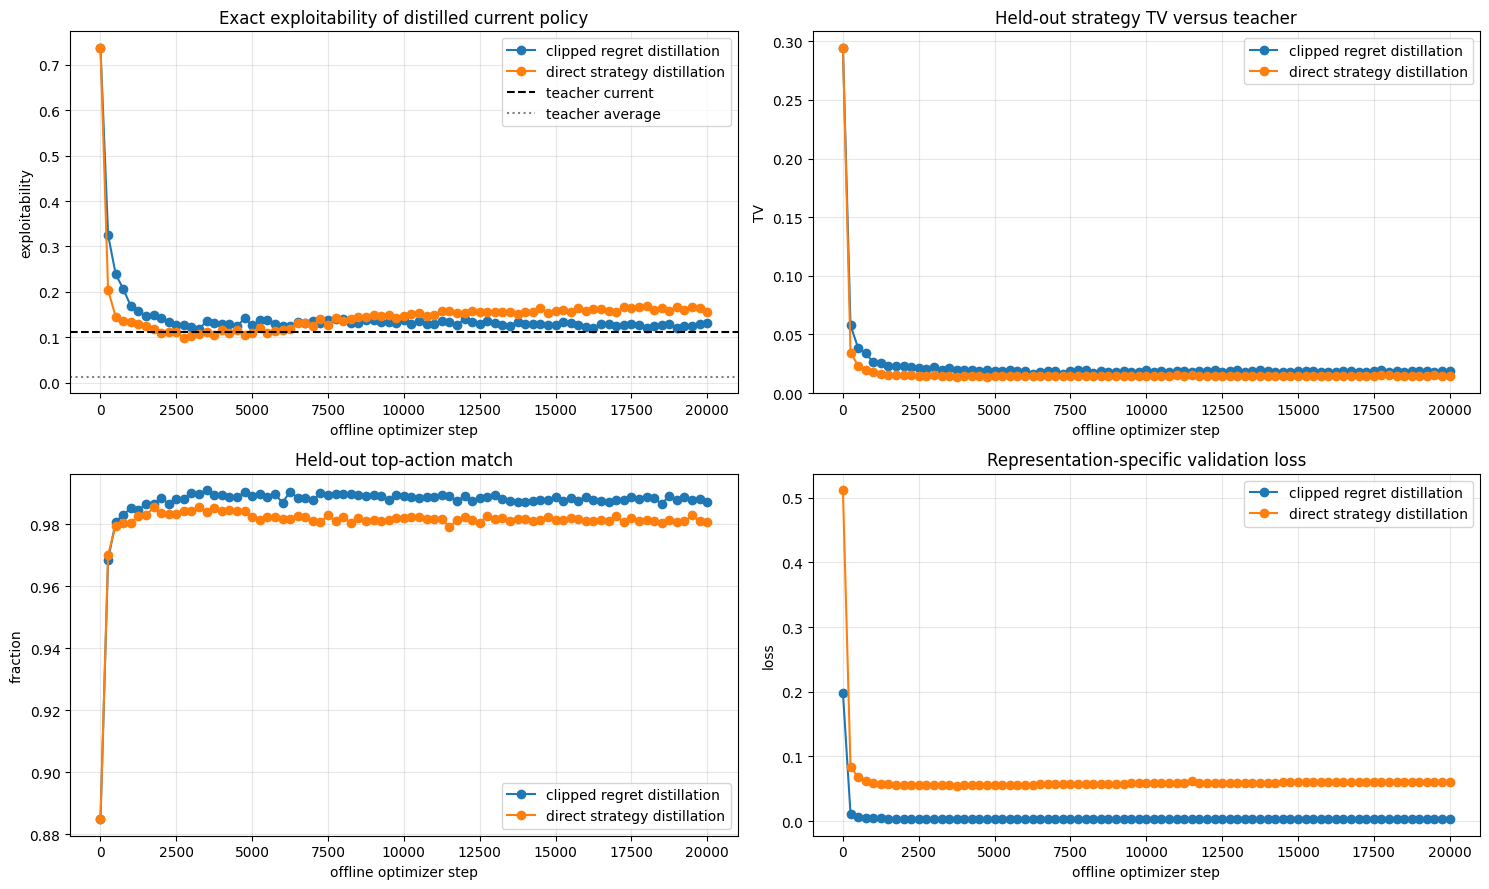

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

ax = axes[0, 0]
for label, group in distill_log.groupby('variant'):
    ax.plot(group['step'], group['exact_exploitability'], marker='o', label=label)
ax.axhline(teacher_current_exp, color='black', linestyle='--', label='teacher current')
ax.axhline(teacher_average_exp, color='gray', linestyle=':', label='teacher average')
ax.set_title('Exact exploitability of distilled current policy')
ax.set_xlabel('offline optimizer step')
ax.set_ylabel('exploitability')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for label, group in distill_log.groupby('variant'):
    ax.plot(group['step'], group['mean_strategy_tv'], marker='o', label=label)
ax.set_title('Held-out strategy TV versus teacher')
ax.set_xlabel('offline optimizer step')
ax.set_ylabel('TV')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for label, group in distill_log.groupby('variant'):
    ax.plot(group['step'], group['mean_top_action_match'], marker='o', label=label)
ax.set_title('Held-out top-action match')
ax.set_xlabel('offline optimizer step')
ax.set_ylabel('fraction')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for label, group in distill_log.groupby('variant'):
    ax.plot(group['step'], group['mean_loss'], marker='o', label=label)
ax.set_title('Representation-specific validation loss')
ax.set_xlabel('offline optimizer step')
ax.set_ylabel('loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()